# EV Charging Optimisation

This notebook finds better EV charging schedules.

## Purpose

Use CVXPY to schedule EV charging so more renewable surplus is used while vehicles still receive energy.

If a scenario cannot be fully served, the notebook records unmet energy instead of simply failing.

Install the optimisation dependency before running:

```bash
poetry add cvxpy
```

In [1]:
from pathlib import Path
import json
import math
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root from either the root or Notebooks directory."""
    current = Path(start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "Data").exists() and (candidate / "Notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing Data/ and Notebooks/.")


ROOT = find_project_root()
DATA_DIR = ROOT / "Data"
RESULTS_DIR = DATA_DIR / "Results"
PROCESSED_DIR = DATA_DIR / "Processed"
FIGURES_DIR = ROOT / "Figures"
MODELS_DIR = ROOT / "Models" / "Forecasting"

for directory in [RESULTS_DIR, PROCESSED_DIR, FIGURES_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

INTERVAL_MINUTES = 5
INTERVAL_HOURS = INTERVAL_MINUTES / 60
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print(f"Project root: {ROOT}")

Project root: /Users/mac/Send-Ev-Project/SEND-EV-Project


In [2]:
def save_table(df: pd.DataFrame, path: Path) -> Path:
    """Save Parquet where available, otherwise save CSV with the same stem."""
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.suffix.lower() == ".parquet":
        try:
            df.to_parquet(path, index=False)
            print(f"Saved: {path.relative_to(ROOT)}")
            return path
        except (ImportError, ModuleNotFoundError) as exc:
            csv_path = path.with_suffix(".csv")
            df.to_csv(csv_path, index=False)
            print(f"Parquet engine unavailable ({exc.__class__.__name__}); saved CSV: {csv_path.relative_to(ROOT)}")
            return csv_path
    df.to_csv(path, index=False)
    print(f"Saved: {path.relative_to(ROOT)}")
    return path


def read_table(path: Path, parse_dates: list[str] | None = None) -> pd.DataFrame:
    """Read a Parquet/CSV output regardless of which format was written."""
    candidates = [path]
    if path.suffix.lower() == ".parquet":
        candidates.append(path.with_suffix(".csv"))
    elif path.suffix.lower() == ".csv":
        candidates.append(path.with_suffix(".parquet"))

    for candidate in candidates:
        if candidate.exists():
            if candidate.suffix.lower() == ".parquet":
                return pd.read_parquet(candidate)
            return pd.read_csv(candidate, parse_dates=parse_dates)
    raise FileNotFoundError(f"None of these files exists: {candidates}")

In [3]:
try:
    import cvxpy as cp
except ImportError as exc:
    raise ImportError("Install CVXPY with: poetry add cvxpy") from exc

scenarios = read_table(DATA_DIR / "ACN" / "processed" / "keele_ev_scenarios.parquet")
send = read_table(PROCESSED_DIR / "send_solcast_surplus_5min.parquet", parse_dates=["DateTime"])
for column in ["arrival_time", "departure_time", "keele_date"]:
    scenarios[column] = pd.to_datetime(scenarios[column], errors="coerce")
send["DateTime"] = pd.to_datetime(send["DateTime"], errors="coerce")

# Add forecast columns if they are saved separately.
for prediction_name in ["surplus_predictions.csv", "surplus_test_features.csv", "forecast_predictions.csv"]:
    prediction_path = RESULTS_DIR / prediction_name
    if not prediction_path.exists():
        continue
    predictions = pd.read_csv(prediction_path, parse_dates=["DateTime"])
    prediction_columns = [c for c in ["surplus_pred_xgb", "surplus_pred_lgbm"] if c in predictions.columns]
    if prediction_columns:
        send = send.merge(
            predictions[["DateTime", *prediction_columns]].drop_duplicates("DateTime"),
            on="DateTime", how="left", suffixes=("", "_new")
        )
        for column in prediction_columns:
            new_column = f"{column}_new"
            if new_column in send.columns:
                send[column] = send[column].combine_first(send[new_column]) if column in send.columns else send[new_column]
                send = send.drop(columns=[new_column])
        print(f"Merged forecast columns from {prediction_name}: {prediction_columns}")

In [4]:
def scenario_time_grid(group: pd.DataFrame, send: pd.DataFrame) -> pd.DatetimeIndex:
    start = pd.Timestamp(group["keele_date"].iloc[0]).normalize()
    latest_departure = pd.to_datetime(group["departure_time"]).max()
    # Use at most 48 hours of SEND data.
    end = min(latest_departure.ceil(f"{INTERVAL_MINUTES}min"), start + pd.Timedelta(hours=48))
    available_end = send["DateTime"].max() + pd.Timedelta(minutes=INTERVAL_MINUTES)
    end = min(end, available_end)
    return pd.date_range(start, end, freq=f"{INTERVAL_MINUTES}min", inclusive="left")


def aligned_send_series(send: pd.DataFrame, grid: pd.DatetimeIndex, column: str) -> np.ndarray:
    series = send.set_index("DateTime")[column].reindex(grid)
    # Fill short gaps; set any remaining gaps to zero.
    return series.interpolate(limit=3).fillna(0).to_numpy(dtype=float)


def schedule_metrics(
    scenario: pd.DataFrame,
    vehicle_schedule: pd.DataFrame,
    send: pd.DataFrame,
    strategy: str,
    forecast_source: str = "none",
) -> dict:
    grid = scenario_time_grid(scenario, send)
    surplus = aligned_send_series(send, grid, "surplus_kw")
    consumption = aligned_send_series(send, grid, "consumption_kw")

    if vehicle_schedule.empty:
        aggregate = pd.Series(0.0, index=grid)
        delivered_by_vehicle = pd.Series(dtype=float)
    else:
        schedule = vehicle_schedule.copy()
        schedule["DateTime"] = pd.to_datetime(schedule["DateTime"])
        aggregate = schedule.groupby("DateTime")["charging_kw"].sum().reindex(grid, fill_value=0.0)
        delivered_by_vehicle = (
            schedule.groupby("vehicle_id")["charging_kw"].sum() * INTERVAL_HOURS
        )

    required = scenario.set_index("vehicle_id")["energy_required_kwh"]
    delivered = delivered_by_vehicle.reindex(required.index, fill_value=0.0)
    service_rate = float((delivered >= required * 0.99).mean())
    unserved = float((required - delivered).clip(lower=0).sum())

    renewable_absorbed = np.minimum(aggregate.to_numpy(), surplus).sum() * INTERVAL_HOURS
    residual_surplus = np.maximum(surplus - aggregate.to_numpy(), 0).sum() * INTERVAL_HOURS
    ev_grid_energy = np.maximum(aggregate.to_numpy() - surplus, 0).sum() * INTERVAL_HOURS

    return {
        "scenario_id": scenario["scenario_id"].iloc[0],
        "keele_date": scenario["keele_date"].iloc[0],
        "scenario_site": scenario["scenario_site"].iloc[0],
        "fleet_size": int(scenario["fleet_size"].iloc[0]),
        "participation_rate": float(scenario["participation_rate"].iloc[0]),
        "participant_count": int(scenario["participant_count"].iloc[0]),
        "site_limit_kw": float(scenario["site_limit_kw"].iloc[0]),
        "strategy": strategy,
        "forecast_source": forecast_source,
        "required_energy_kwh": float(required.sum()),
        "delivered_energy_kwh": float(delivered.sum()),
        "unserved_energy_kwh": unserved,
        "service_rate": service_rate,
        "renewable_absorbed_kwh": float(renewable_absorbed),
        "residual_surplus_kwh": float(residual_surplus),
        "ev_grid_energy_kwh": float(ev_grid_energy),
        "peak_ev_kw": float(aggregate.max()),
        "peak_total_load_kw": float((aggregate.to_numpy() + consumption).max()),
    }

## 1. Discover available surplus signals

In [5]:
FORECAST_COLUMN_CANDIDATES = {
    "actual": "surplus_kw",
    "xgb": "surplus_pred_xgb",
    "lgbm": "surplus_pred_lgbm",
}

available_sources = {
    name: column for name, column in FORECAST_COLUMN_CANDIDATES.items() if column in send.columns
}
print("Available optimisation signals:", available_sources)

if "actual" not in available_sources:
    raise KeyError("The processed SEND file must contain surplus_kw.")

Available optimisation signals: {'actual': 'surplus_kw'}


## 2. Optimisation model

In [6]:
def solve_scenario(
    scenario: pd.DataFrame,
    send: pd.DataFrame,
    forecast_source: str,
    forecast_column: str,
    unserved_penalty: float = 10_000.0,
    grid_penalty: float = 5.0,
    residual_penalty: float = 1.0,
    smoothness_penalty: float = 0.001,
) -> tuple[pd.DataFrame, dict]:
    group = scenario.copy().sort_values("vehicle_id").reset_index(drop=True)
    grid = scenario_time_grid(group, send)
    n_vehicles, n_steps = len(group), len(grid)

    arrival = group["arrival_time"].to_numpy(dtype="datetime64[ns]")
    departure = group["departure_time"].to_numpy(dtype="datetime64[ns]")
    grid_values = grid.to_numpy(dtype="datetime64[ns]")
    availability = (
        (grid_values[None, :] >= arrival[:, None])
        & (grid_values[None, :] < departure[:, None])
    ).astype(float)

    max_power = group["max_power_kw"].to_numpy(dtype=float)
    efficiency = group["efficiency"].to_numpy(dtype=float)
    required = group["energy_required_kwh"].to_numpy(dtype=float)
    site_limit = float(group["site_limit_kw"].iloc[0])
    signal = np.maximum(aligned_send_series(send, grid, forecast_column), 0)

    charging = cp.Variable((n_vehicles, n_steps), nonneg=True)
    unserved = cp.Variable(n_vehicles, nonneg=True)
    aggregate = cp.sum(charging, axis=0)

    delivered = cp.multiply(efficiency, cp.sum(charging, axis=1) * INTERVAL_HOURS)
    constraints = [
        charging <= max_power[:, None] * availability,
        aggregate <= site_limit,
        delivered + unserved >= required,
    ]

    residual_surplus = cp.pos(signal - aggregate)
    grid_supported = cp.pos(aggregate - signal)
    smoothness = cp.sum_squares(aggregate[1:] - aggregate[:-1]) if n_steps > 1 else 0

    objective = cp.Minimize(
        unserved_penalty * cp.sum(unserved)
        + residual_penalty * cp.sum(residual_surplus) * INTERVAL_HOURS
        + grid_penalty * cp.sum(grid_supported) * INTERVAL_HOURS
        + smoothness_penalty * smoothness
    )
    problem = cp.Problem(objective, constraints)

    installed = set(cp.installed_solvers())
    solver_order = [solver for solver in ["CLARABEL", "OSQP", "SCS"] if solver in installed]
    if not solver_order:
        raise RuntimeError("No compatible CVXPY solver is installed.")

    last_error = None
    for solver in solver_order:
        try:
            problem.solve(solver=solver, verbose=False)
            if problem.status in {cp.OPTIMAL, cp.OPTIMAL_INACCURATE}:
                break
        except Exception as exc:
            last_error = exc
    else:
        raise RuntimeError(f"Optimisation failed: {problem.status}; {last_error}")

    values = np.maximum(np.asarray(charging.value), 0)
    records = []
    for i, vehicle in group.iterrows():
        active_steps = np.flatnonzero(values[i] > 1e-5)
        for t in active_steps:
            records.append({
                "scenario_id": vehicle["scenario_id"],
                "vehicle_id": vehicle["vehicle_id"],
                "DateTime": grid[t],
                "charging_kw": values[i, t],
                "strategy": f"optimised_{forecast_source}",
                "forecast_source": forecast_source,
            })

    schedule = pd.DataFrame(records)
    metrics = schedule_metrics(
        group, schedule, send, strategy=f"optimised_{forecast_source}", forecast_source=forecast_source
    )
    metrics.update({
        "solver_status": problem.status,
        "objective_value": float(problem.value),
        "solver_used": solver,
        "reported_unserved_variable_kwh": float(np.maximum(np.asarray(unserved.value), 0).sum()),
    })
    return schedule, metrics

## 3. Run perfect-information and forecast-informed cases

In [7]:
# Start small because optimisation can take time.
# Use None for the full run.
MAX_SCENARIOS = 24
scenario_ids = scenarios["scenario_id"].drop_duplicates().tolist()
if MAX_SCENARIOS is not None:
    scenario_ids = scenario_ids[:MAX_SCENARIOS]

schedule_frames = []
metric_rows = []
for count, scenario_id in enumerate(scenario_ids, start=1):
    scenario = scenarios[scenarios["scenario_id"].eq(scenario_id)].copy()
    for source, column in available_sources.items():
        schedule, metrics = solve_scenario(scenario, send, source, column)
        schedule_frames.append(schedule)
        metric_rows.append(metrics)
    print(f"Completed {count}/{len(scenario_ids)}: {scenario_id}")

optimised_schedule = pd.concat(schedule_frames, ignore_index=True) if schedule_frames else pd.DataFrame()
optimisation_metrics = pd.DataFrame(metric_rows)
display(optimisation_metrics.groupby("strategy")[[
    "service_rate", "renewable_absorbed_kwh", "residual_surplus_kwh", "ev_grid_energy_kwh"
]].mean())

Completed 1/24: 20230707_pooled_F10_P025_S42
Completed 2/24: 20230707_pooled_F10_P025_S43
Completed 3/24: 20230707_pooled_F10_P050_S42
Completed 4/24: 20230707_pooled_F10_P050_S43
Completed 5/24: 20230707_pooled_F10_P075_S42


/Users/mac/Library/Caches/pypoetry/virtualenvs/send-ev-project-11oc5mOD-py3.12/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Completed 6/24: 20230707_pooled_F10_P075_S43
Completed 7/24: 20230707_pooled_F10_P100_S42
Completed 8/24: 20230707_pooled_F10_P100_S43
Completed 9/24: 20230707_pooled_F25_P025_S42
Completed 10/24: 20230707_pooled_F25_P025_S43


/Users/mac/Library/Caches/pypoetry/virtualenvs/send-ev-project-11oc5mOD-py3.12/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Completed 11/24: 20230707_pooled_F25_P050_S42
Completed 12/24: 20230707_pooled_F25_P050_S43
Completed 13/24: 20230707_pooled_F25_P075_S42
Completed 14/24: 20230707_pooled_F25_P075_S43
Completed 15/24: 20230707_pooled_F25_P100_S42
Completed 16/24: 20230707_pooled_F25_P100_S43
Completed 17/24: 20230707_pooled_F50_P025_S42
Completed 18/24: 20230707_pooled_F50_P025_S43
Completed 19/24: 20230707_pooled_F50_P050_S42
Completed 20/24: 20230707_pooled_F50_P050_S43
Completed 21/24: 20230707_pooled_F50_P075_S42
Completed 22/24: 20230707_pooled_F50_P075_S43
Completed 23/24: 20230707_pooled_F50_P100_S42
Completed 24/24: 20230707_pooled_F50_P100_S43


,service_rate,renewable_absorbed_kwh,residual_surplus_kwh,ev_grid_energy_kwh
strategy,,,,
optimised_actual,1.0,584.140466,12111.463959,32.483762


## 4. Save outputs

In [8]:
save_table(optimised_schedule, RESULTS_DIR / "optimised_vehicle_schedule.parquet")
save_table(optimisation_metrics, RESULTS_DIR / "optimisation_metrics.csv")

Saved: Data/Results/optimised_vehicle_schedule.parquet
Saved: Data/Results/optimisation_metrics.csv


PosixPath('/Users/mac/Send-Ev-Project/SEND-EV-Project/Data/Results/optimisation_metrics.csv')

## 5. Visual comparison for one scenario

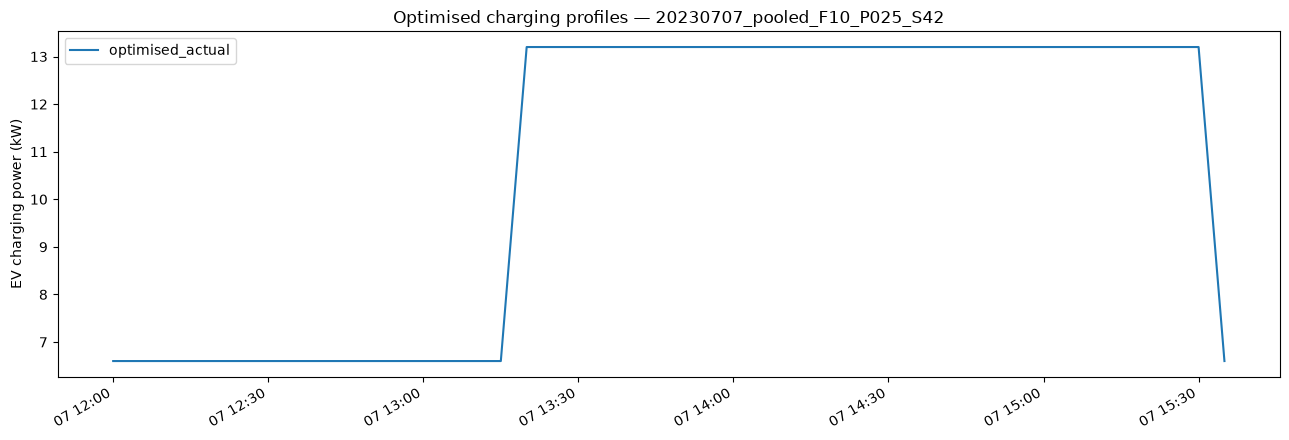

In [9]:
if not optimised_schedule.empty:
    example_id = optimised_schedule["scenario_id"].iloc[0]
    example = optimised_schedule[optimised_schedule["scenario_id"].eq(example_id)]
    aggregate = example.groupby(["strategy", "DateTime"], as_index=False)["charging_kw"].sum()

    fig, ax = plt.subplots(figsize=(13, 4.5))
    for strategy, frame in aggregate.groupby("strategy"):
        ax.plot(frame["DateTime"], frame["charging_kw"], label=strategy)
    ax.set_title(f"Optimised charging profiles — {example_id}")
    ax.set_ylabel("EV charging power (kW)")
    ax.legend()
    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "optimised_charging_profile.png", dpi=200, bbox_inches="tight")
    plt.show()